# Grid Search

## Baseline

===== ÉVALUATION (CV=5 folds) POUR : **xgboost** (SMOTE=False, Scaler=none) =====

--- Scores de Validation Croisée (moyenne) ---

| Métrique | Score | Écart-type |
| :--- | :--- | :--- |
| Accuracy | 0.8592 | +- 0.0199 |
| Precision | 0.7452 | +- 0.0506 |
| Recall | 0.6743 | +- 0.0327 |
| F1-Score | 0.6989 | +- 0.0384 |

In [49]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
import xgboost as xgb
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import (
    GridSearchCV,
    KFold,
    StratifiedKFold,
    cross_val_score,
)
from sklearn.pipeline import Pipeline  # Utiliser la Pipeline standard de Scikit-learn
from sklearn.preprocessing import OneHotEncoder
import seaborn as sns


In [24]:
df = pd.read_csv("processed/data_merge_p2.csv", index_col=0)
X = df.drop('a_quitte_l_entreprise', axis=1)
y = df['a_quitte_l_entreprise']
colonnes_categorielles = ['frequence_deplacement', 
                          'domaine_etude', 
                          'poste', 
                          'departement', 
                          'statut_marital']
colonnes_numeriques = X.select_dtypes(include=np.number).columns

In [25]:
preprocessor = ColumnTransformer(
    transformers=[
        # Applique OneHotEncoder aux colonnes catégorielles
        ('onehot', OneHotEncoder(handle_unknown='ignore'), colonnes_categorielles),
        
        # 'passthrough' pour les colonnes numériques (pas de scaling)
        ('scaler', 'passthrough', colonnes_numeriques)
    ],
    remainder='passthrough'
)

In [26]:
# Puisque SMOTE n'est pas utilisé, on utilise 'scale_pos_weight' pour gérer le déséquilibre
scale_pos_weight = (y == 0).sum() / (y == 1).sum()
model_xgb = xgb.XGBClassifier(random_state=42, scale_pos_weight=scale_pos_weight)

In [27]:
# ('preprocessor' pour les étapes de transfo, 'model' pour l'estimateur)
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', model_xgb) # 'model' est le nom que nous donnons à l'étape XGBoost
])

In [42]:
# ATTENTION : Les noms DOIVENT commencer par le nom de l'étape : 'model__'
param_grid = {
    'model__n_estimators': [50, 100, 200, 400, 600],       # Nombre d'arbres
    'model__max_depth': [3, 5, 7, 9, 12],                  # Profondeur max des arbres
    'model__learning_rate': [0.005, 0.01, 0.1, 0.2, 0.3],  # Taux d'apprentissage
    # min_child_weight : Poids minimum requis dans un "enfant" (feuille).
    # Une valeur plus élevée rend le modèle plus conservateur.
    'model__min_child_weight': [1, 3, 5, 10],
    # subsample : Fraction d'échantillons (lignes) utilisée pour chaque arbre.
    # 0.8 signifie que chaque arbre est entraîné sur 80% des données.
    'model__subsample': [0.7, 0.8, 0.9, 1.0],
    'model__colsample_bytree': [0.7, 0.8, 0.9, 1.0]
}

In [43]:
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print("--- Lancement du GridSearchCV pour XGBoost ---")

grid_search = GridSearchCV(
    estimator=pipeline,       # On passe la pipeline complète !
    param_grid=param_grid,    # La grille de paramètres préfixée
    scoring='f1_macro',       # Métrique pertinente pour données déséquilibrées
    cv=cv_strategy,           # Notre stratégie de CV stratifiée
    n_jobs=-1,                # Utiliser tous les processeurs
    verbose=1                 # Afficher la progression
)

--- Lancement du GridSearchCV pour XGBoost ---


In [44]:
grid_search.fit(X, y)

Fitting 5 folds for each of 8000 candidates, totalling 40000 fits


,estimator,"Pipeline(step...=None, ...))])"
,param_grid,"{'model__colsample_bytree': [0.7, 0.8, ...], 'model__learning_rate': [0.005, 0.01, ...], 'model__max_depth': [3, 5, ...], 'model__min_child_weight': [1, 3, ...], ...}"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('onehot', ...), ('scaler', ...)]"


In [45]:
print("\n--- RÉSULTATS DU GRIDSEARCH ---")
print(f"Meilleurs hyperparamètres trouvés :")
print(grid_search.best_params_)

print(f"\nMeilleur score (f1_macro) sur la validation croisée :")
print(f"{grid_search.best_score_:.4f}")

# 9. Utiliser le meilleur modèle
# 'grid_search' est maintenant le meilleur modèle, ré-entraîné sur TOUT X et y
best_model = grid_search.best_estimator_


--- RÉSULTATS DU GRIDSEARCH ---
Meilleurs hyperparamètres trouvés :
{'model__colsample_bytree': 1.0, 'model__learning_rate': 0.2, 'model__max_depth': 9, 'model__min_child_weight': 5, 'model__n_estimators': 50, 'model__subsample': 0.9}

Meilleur score (f1_macro) sur la validation croisée :
0.7590


--- Analyse 1 : Importance Native (Gain) ---


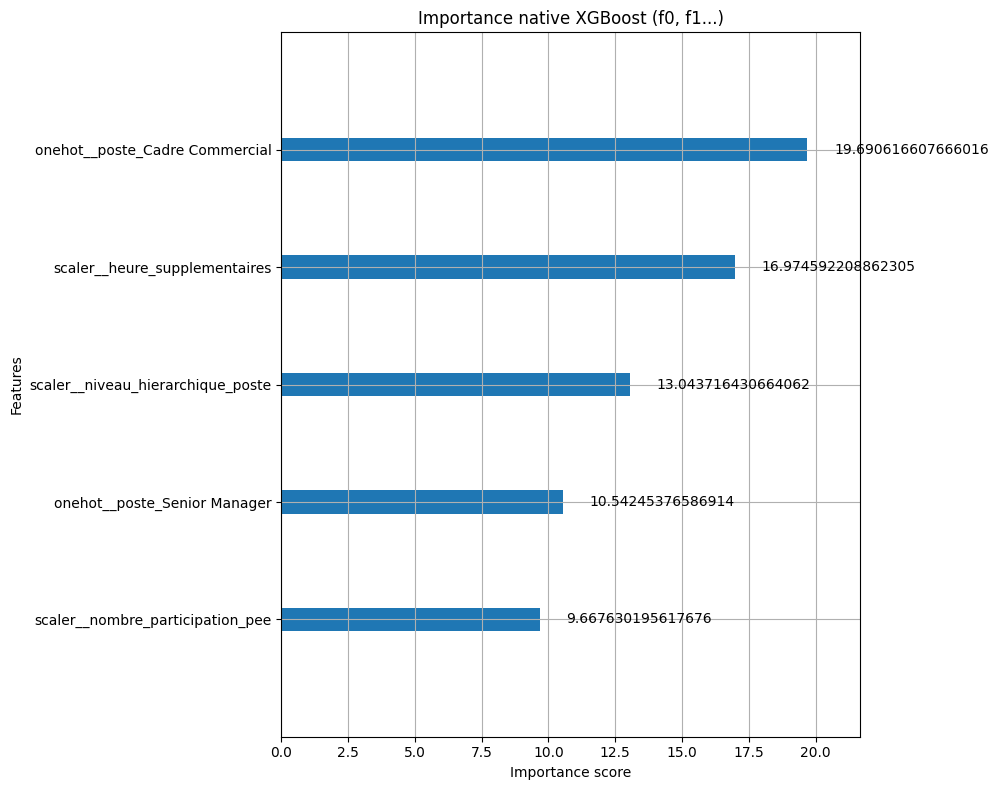

In [46]:
best_pipeline = grid_search.best_estimator_
best_xgb_model = best_pipeline.named_steps['model']
trained_preprocessor = best_pipeline.named_steps['preprocessor']
feature_names_out = list(trained_preprocessor.get_feature_names_out())
best_xgb_model.get_booster().feature_names = feature_names_out
print("--- Analyse 1 : Importance Native (Gain) ---")

fig, ax = plt.subplots(figsize=(10, 8))
try:
    xgb.plot_importance(best_xgb_model, 
                        ax=ax, 
                        importance_type='gain', 
                        max_num_features=5,
                        title="Importance native XGBoost (f0, f1...)")
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Erreur lors de l'affichage de plot_importance (attendu si les noms manquent) : {e}")


--- Analyse 2 : Interprétabilité avec SHAP ---


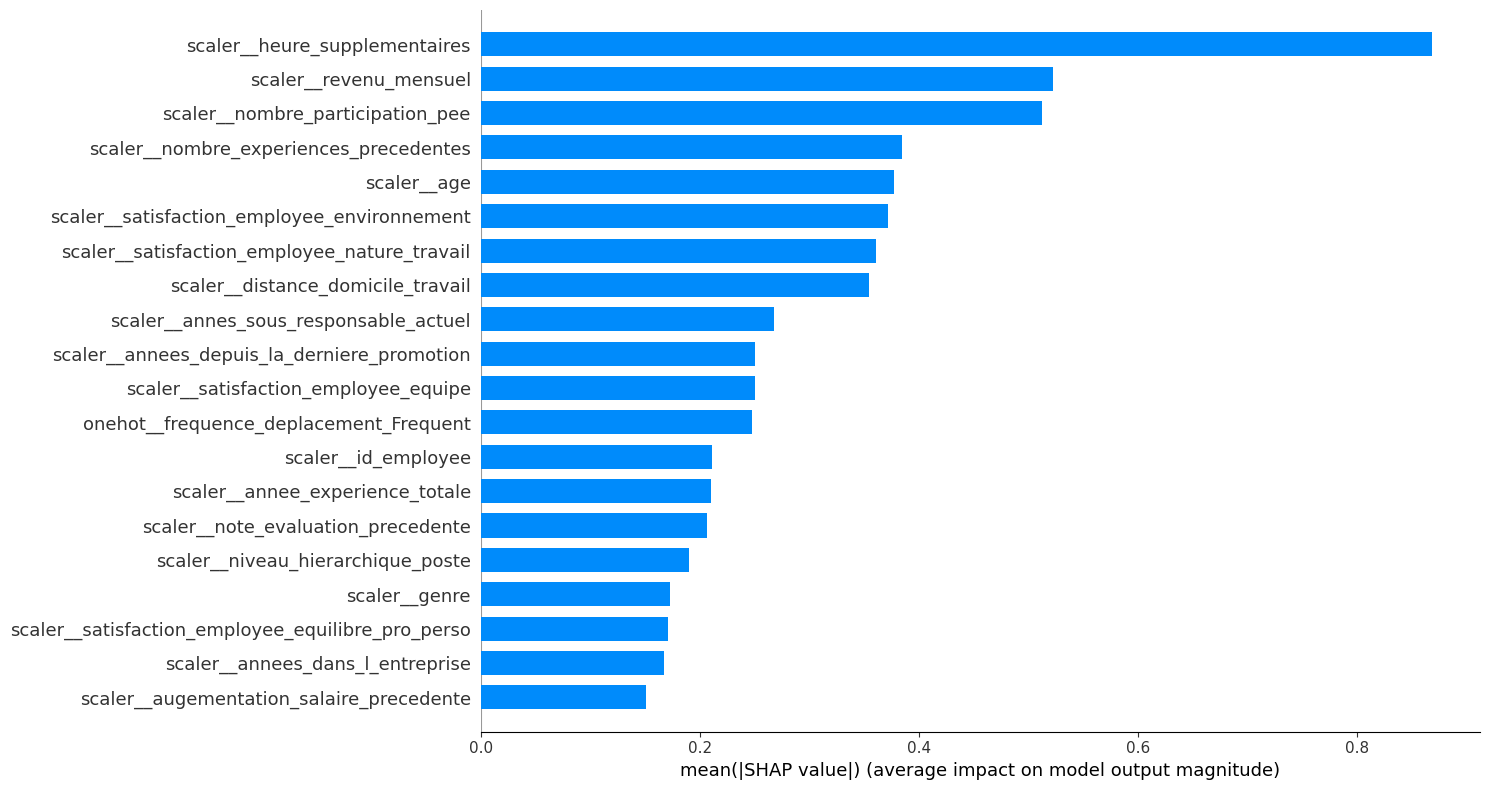

In [47]:
print("\n--- Analyse 2 : Interprétabilité avec SHAP ---")
feature_names = trained_preprocessor.get_feature_names_out()
X_processed = trained_preprocessor.transform(X)
explainer = shap.TreeExplainer(best_xgb_model)
shap_values = explainer.shap_values(X_processed)
shap.summary_plot(shap_values, X_processed, feature_names=feature_names, plot_type='bar', plot_size=(15,8))


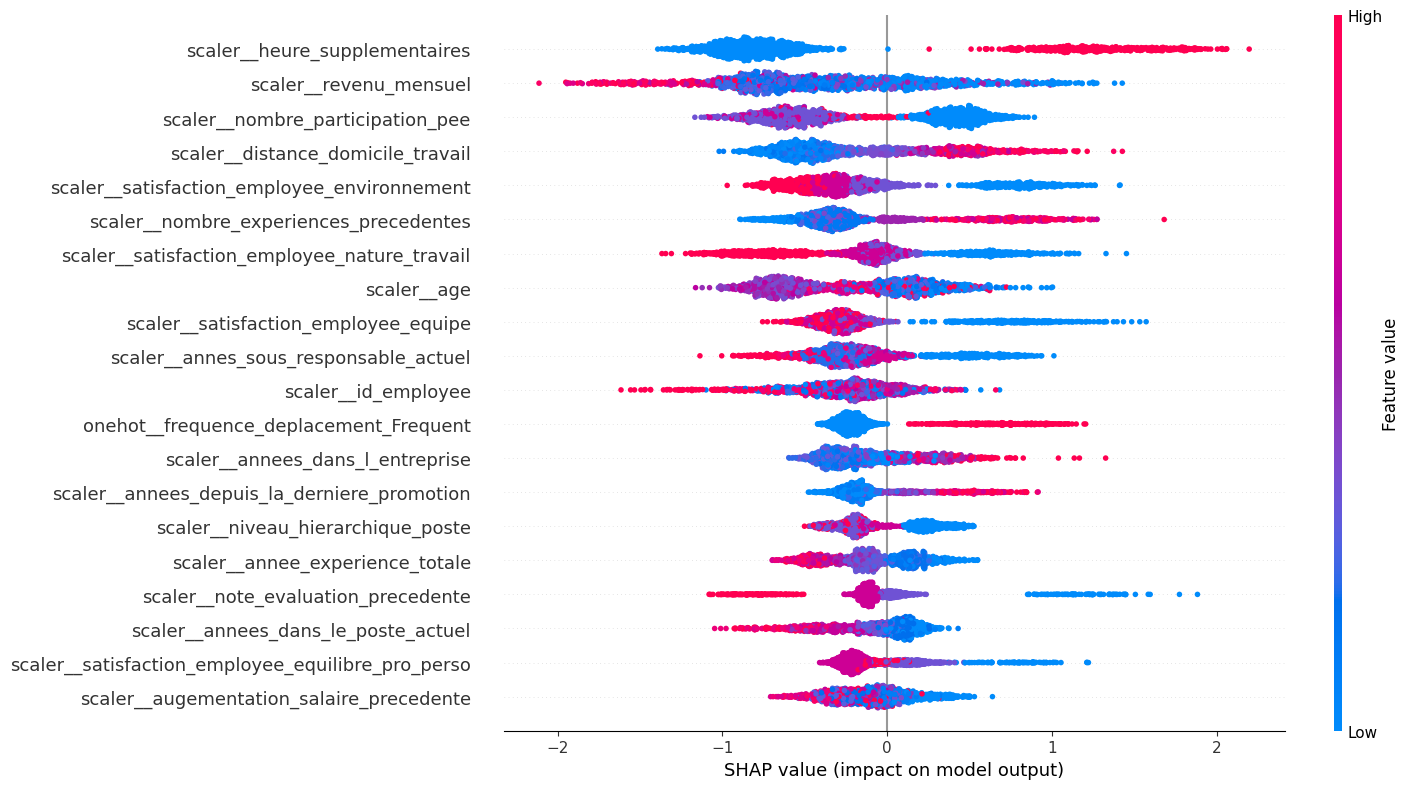

In [34]:
shap.summary_plot(shap_values, X_processed, feature_names=feature_names, plot_size=(15,8))

In [35]:
X_processed_df = pd.DataFrame(X_processed, columns=feature_names)

# Créer l'explicateur
#explainer = shap.TreeExplainer(best_xgb_model)

# Obtenir les explications avec noms
shap_explanations = explainer(X_processed_df)

# Vérifier si les noms sont présents
print(shap_explanations[0].feature_names)

['onehot__frequence_deplacement_Aucun', 'onehot__frequence_deplacement_Frequent', 'onehot__frequence_deplacement_Occasionnel', 'onehot__domaine_etude_Autre', 'onehot__domaine_etude_Entrepreunariat', 'onehot__domaine_etude_Infra & Cloud', 'onehot__domaine_etude_Marketing', 'onehot__domaine_etude_Ressources Humaines', 'onehot__domaine_etude_Transformation Digitale', 'onehot__poste_Assistant de Direction', 'onehot__poste_Cadre Commercial', 'onehot__poste_Consultant', 'onehot__poste_Directeur Technique', 'onehot__poste_Manager', 'onehot__poste_Représentant Commercial', 'onehot__poste_Ressources Humaines', 'onehot__poste_Senior Manager', 'onehot__poste_Tech Lead', 'onehot__departement_Commercial', 'onehot__departement_Consulting', 'onehot__departement_Ressources Humaines', 'onehot__statut_marital_Célibataire', 'onehot__statut_marital_Divorcé(e)', 'onehot__statut_marital_Marié(e)', 'scaler__id_employee', 'scaler__age', 'scaler__genre', 'scaler__revenu_mensuel', 'scaler__nombre_experiences_pr

['onehot__frequence_deplacement_Aucun', 'onehot__frequence_deplacement_Frequent', 'onehot__frequence_deplacement_Occasionnel', 'onehot__domaine_etude_Autre', 'onehot__domaine_etude_Entrepreunariat', 'onehot__domaine_etude_Infra & Cloud', 'onehot__domaine_etude_Marketing', 'onehot__domaine_etude_Ressources Humaines', 'onehot__domaine_etude_Transformation Digitale', 'onehot__poste_Assistant de Direction', 'onehot__poste_Cadre Commercial', 'onehot__poste_Consultant', 'onehot__poste_Directeur Technique', 'onehot__poste_Manager', 'onehot__poste_Représentant Commercial', 'onehot__poste_Ressources Humaines', 'onehot__poste_Senior Manager', 'onehot__poste_Tech Lead', 'onehot__departement_Commercial', 'onehot__departement_Consulting', 'onehot__departement_Ressources Humaines', 'onehot__statut_marital_Célibataire', 'onehot__statut_marital_Divorcé(e)', 'onehot__statut_marital_Marié(e)', 'scaler__id_employee', 'scaler__age', 'scaler__genre', 'scaler__revenu_mensuel', 'scaler__nombre_experiences_pr

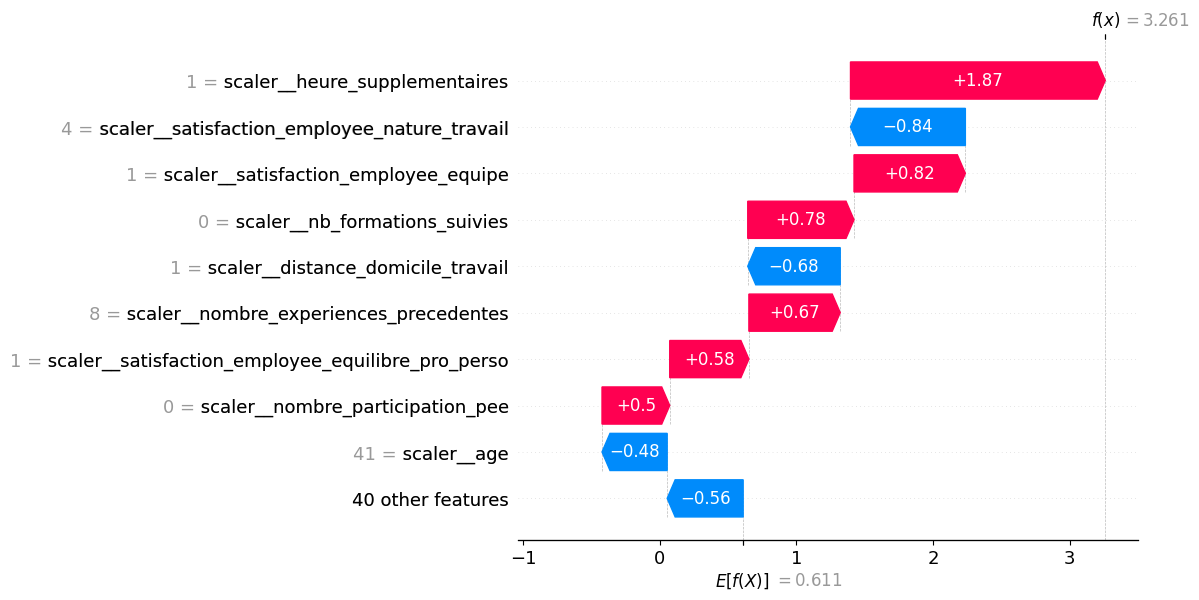

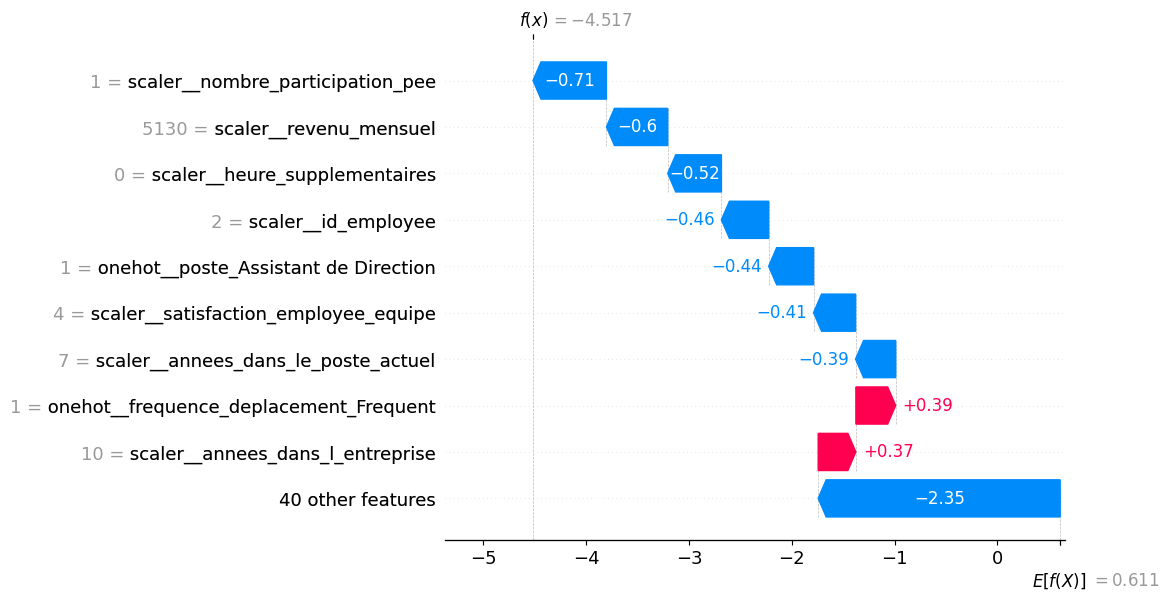

In [36]:
idx1 = 0  # par exemple, le premier individu
idx2 = 1  # le deuxième individu
# Waterfall plot pour le premier individu
#shap_explanations = explainer(X_processed)
print(shap_explanations[0].feature_names)
shap.waterfall_plot(shap_explanations[idx1])

# Waterfall plot pour le deuxième individu
shap.waterfall_plot(shap_explanations[idx2])

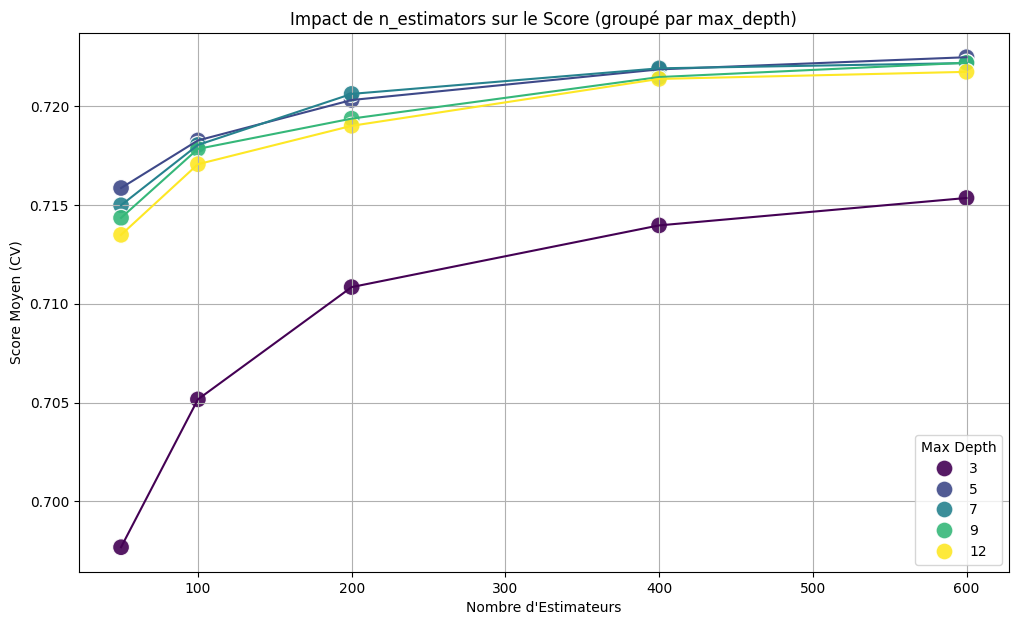

In [54]:
results = pd.DataFrame(grid_search.cv_results_)
param_1 = 'param_model__n_estimators'
param_2 = 'param_model__max_depth'
param_3 = 'param_model__learning_rate'
score_col = 'mean_test_score' # Le score moyen de la validation croisée


aggregated_results = results.groupby([param_1, param_2])[score_col].mean().reset_index()

plt.figure(figsize=(12, 7))
sns.scatterplot(data=aggregated_results,
                x=param_1,
                y=score_col,
                hue=param_2,  # Couleur basée sur max_depth
                palette='viridis', # Palette de couleurs
                s=150,        # Taille des points
                alpha=0.9)

sns.lineplot(data=aggregated_results,
             x=param_1,
             y=score_col,
             hue=param_2,
             palette='viridis',
             legend=False) # Pas besoin de 2e légende

plt.title('Impact de n_estimators sur le Score (groupé par max_depth)')
plt.xlabel('Nombre d\'Estimateurs')
plt.ylabel('Score Moyen (CV)')
plt.legend(title='Max Depth')
plt.grid(True)
plt.show()

# Test Optuna

In [37]:
import optuna
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

model_params_fixed = {
        'objective': 'binary:logistic',
        'eval_metric': 'logloss'
    }

In [38]:
from sklearn.model_selection import train_test_split


def objective(trial, X, y):
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    X_train_enc = encoder.fit_transform(X_train)
    X_test_enc = encoder.transform(X_test)

    param = {
        'objective': 'binary:logistic',  # Pour la classification binaire
        'eval_metric': 'logloss',          # Métrique d'évaluation interne
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000, step=100), # Nb d'arbres
        'max_depth': trial.suggest_int('max_depth', 3, 10),                     # Profondeur max
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),     # Taux d'apprentissage
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),              # % d'échantillons par arbre
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),  # % de features par arbre
        'gamma': trial.suggest_float('gamma', 0, 5),                            # Réduction de perte minimum
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 5),                    # Régularisation L1
        'reg_lambda': trial.suggest_float('reg_lambda', 0, 5),                  # Régularisation L2
        'random_state': 42 # Pour la reproductibilité
    }

    model_xgb = xgb.XGBClassifier(**param) # On passe tous les params d'un coup
    
    model_xgb.fit(X_train_enc, y_train,
                  eval_set=[(X_test_enc, y_test)], # On évalue sur la VALIDATION
                  verbose=False)             # N'affiche pas les logs d'entraînement

    preds = model_xgb.predict(X_test_enc)
    
    # On calcule l'accuracy (précision)
    f1_macro = f1_score(y_test, preds, average='macro')    
    # 2d. Renvoyer le score à Optuna
    # Optuna essaiera de MAXIMISER cette valeur
    return f1_macro

In [40]:
print("\n--- Démarrage de l'optimisation Optuna ---")

# On crée une "étude". 
# direction="maximize" car nous voulons maximiser le f1.
study = optuna.create_study(direction="maximize")

# On lance l'optimisation !
# Optuna va appeler la fonction 'objective' 50 fois (n_trials=50)
study.optimize(lambda trail: objective(trail, X, y), n_trials=50)

# --- ÉTAPE 4 : Afficher les résultats ---

print("\n--- Optimisation terminée ---")
print(f"Nombre d'essais terminés : {len(study.trials)}")

print("Meilleur essai :")
best_trial = study.best_trial

### CHANGEMENT : Le label affiche F1-Score ###
print(f"Valeur (F1-Score Macro) : {best_trial.value:.4f}")

print("Meilleurs Hyperparamètres :")
for key, value in best_trial.params.items():
    print(f"{key}: {value}")

scores = [trial.value for trial in study.trials]

# Calculer l'écart type
ecart_type = np.std(scores)

print(f"Écart type des scores : {ecart_type}")

[I 2025-11-10 10:54:16,023] A new study created in memory with name: no-name-0f5c2adf-e9d4-4a34-9ce7-499dc33a602e



--- Démarrage de l'optimisation Optuna ---


[I 2025-11-10 10:54:16,838] Trial 0 finished with value: 0.5855263157894737 and parameters: {'n_estimators': 300, 'max_depth': 10, 'learning_rate': 0.057190018678106705, 'subsample': 0.7624445079895001, 'colsample_bytree': 0.7214749285930147, 'gamma': 4.315688727508682, 'reg_alpha': 3.7493898155358756, 'reg_lambda': 4.596789919683517}. Best is trial 0 with value: 0.5855263157894737.
[I 2025-11-10 10:54:18,203] Trial 1 finished with value: 0.6175339366515837 and parameters: {'n_estimators': 600, 'max_depth': 5, 'learning_rate': 0.11003706455777773, 'subsample': 0.7681465392383866, 'colsample_bytree': 0.7578460462428362, 'gamma': 3.2489665177961804, 'reg_alpha': 0.15641349068259147, 'reg_lambda': 4.4794616369864535}. Best is trial 1 with value: 0.6175339366515837.
[I 2025-11-10 10:54:20,539] Trial 2 finished with value: 0.6798190500125659 and parameters: {'n_estimators': 1000, 'max_depth': 5, 'learning_rate': 0.23253850829022366, 'subsample': 0.8681392504219405, 'colsample_bytree': 0.659


--- Optimisation terminée ---
Nombre d'essais terminés : 50
Meilleur essai :
Valeur (F1-Score Macro) : 0.7217
Meilleurs Hyperparamètres :
n_estimators: 800
max_depth: 4
learning_rate: 0.2876910914516274
subsample: 0.537250120505303
colsample_bytree: 0.9982193748638531
gamma: 2.0850713358934665
reg_alpha: 0.40021625381098236
reg_lambda: 1.6902578699542241
Écart type des scores : 0.037822940570064745


--- Optimisation terminée ---

Nombre d'essais terminés : 50

    Meilleur essai :

        Valeur (F1-Score Macro) : 0.7263

        Meilleurs Hyperparamètres :

            n_estimators: 500

            max_depth: 4

            learning_rate: 0.28277892727029286

            subsample: 0.7388139052114349

            colsample_bytree: 0.570311238759169

            gamma: 0.24512087731543233

            reg_alpha: 0.29665027319123105

            reg_lambda: 2.3568123096248654




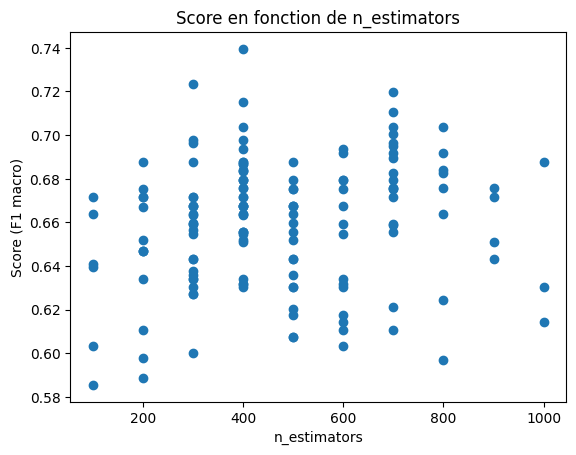

In [ ]:
df_trials = study.trials_dataframe()

# Tracer le scatter plot
plt.scatter(df_trials['params_n_estimators'], df_trials['value'])
plt.xlabel('n_estimators')
plt.ylabel('Score (F1 macro)')
plt.title('Score en fonction de n_estimators')
plt.show()

#calculer moyenne f score / théoreme central limite 

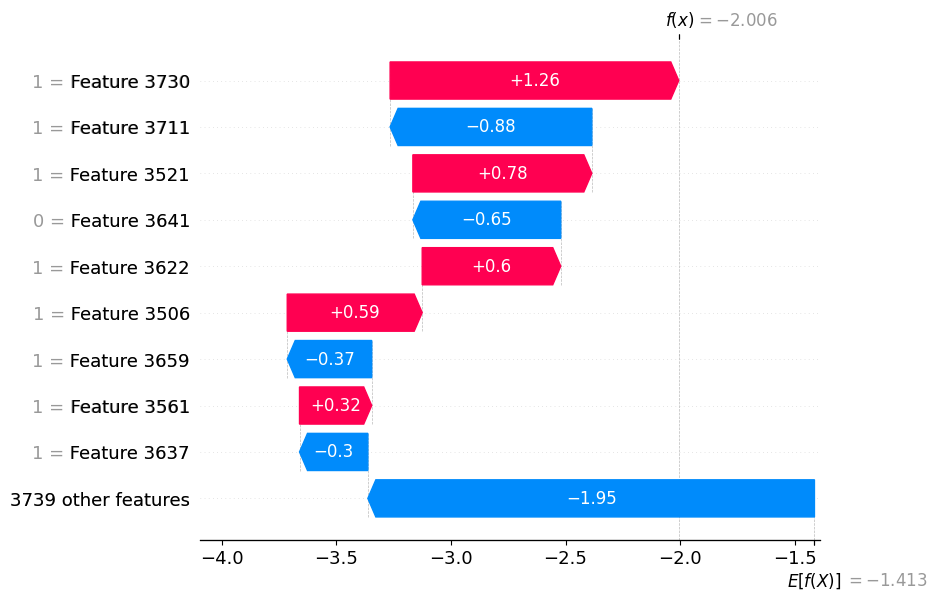

In [ ]:
best_trial = study.best_trial

# Récupérer les paramètres du meilleur trial
best_params = best_trial.params

# Refaire l'entraînement avec ces paramètres
# (en utilisant la même procédure que dans votre fonction objective)
# Assurez-vous d'avoir X et y disponibles

# Split et encodage
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_train_enc = encoder.fit_transform(X_train)
X_test_enc = encoder.transform(X_test)

# Entraîner le modèle
model = xgb.XGBClassifier(**best_params)
model.fit(X_train_enc, y_train)

# Obtenir l'explication SHAP
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_test_enc)

# Identifier l'individu à analyser (par exemple, le premier)
idx = 0

# Waterfall plot
shap.waterfall_plot(shap_values[idx])

# Optimisation du seuil 

Seuil optimal : 0.54 avec un score F1 de 0.714


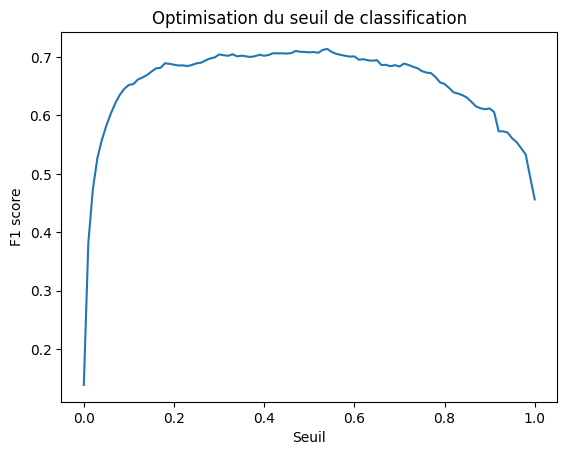

In [ ]:
from sklearn.calibration import cross_val_predict


best_model = grid_search.best_estimator_
probas = cross_val_predict(best_model, X, y, cv=5, method='predict_proba')[:, 1]
seuils = np.linspace(0, 1, 101)
scores = []

for seuil in seuils:
    preds = (probas >= seuil).astype(int)
    score = f1_score(y, preds, average='macro')
    scores.append(score)

best_idx = np.argmax(scores)
best_seuil = seuils[best_idx]
best_score = scores[best_idx]

print(f"Seuil optimal : {best_seuil:.2f} avec un score F1 de {best_score:.3f}")

plt.plot(seuils, scores)
plt.xlabel('Seuil')
plt.ylabel('F1 score')
plt.title('Optimisation du seuil de classification')
plt.show()

# plot auroc ?

In [ ]:
best_params = study.best_trial.params
best_model = xgb.XGBClassifier(**best_params, use_label_encoder=False, eval_metric='logloss')
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_train_enc = encoder.fit_transform(X_train)
X_test_enc = encoder.transform(X_test)

# Entraîner le modèle
model = xgb.XGBClassifier(**best_params)
model.fit(X_train_enc, y_train)

# 3. Obtenir probabilités sur tout le dataset
probas = model.predict_proba(X_test_enc)[:, 1]

# 4. Recherche du seuil optimal
seuils = np.linspace(0, 1, 101)
scores = []

for seuil in seuils:
    preds = (probas >= seuil).astype(int)
    score = f1_score(y_test, preds, average='macro')
    scores.append(score)

best_idx = np.argmax(scores)
best_seuil = seuils[best_idx]
print(f"Seuil optimal : {best_seuil:.2f} avec un score F1 de {scores[best_idx]:.3f}")

Seuil optimal : 0.50 avec un score F1 de 0.733


In [ ]:
1-y_test.sum()/len(y_test)

np.float64(0.8401360544217686)